## 프로젝트 : 모든 장르 간 편향성 측정해 보기

수업에서는 예술영화 · 일반영화(target)를 드라마 · 멜로로맨스 · 액션 · 코미디 · 전쟁 · 공포(호러) 6개 장르(attribute)와만 비교해서 WEAT score를 구했다. 이 프로젝트에서는 그 범위를 21개 장르 전체로 넓혀서, 예술영화-일반영화 축에 대해 모든 장르 쌍이 어떤 편향성을 보이는지 21x21 행렬로 구해본다.

### 준비 1. 라이브러리 설치 및 임포트

In [ ]:
!pip install konlpy
!pip install gensim

import os
import re
import numpy as np
from numpy import dot
from numpy.linalg import norm
from konlpy.tag import Okt
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

print("임포트 완료")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 27.5 MB/s eta 0:00:00
임포트 완료


### 준비 2. WEAT score 계산 함수 정의

앞에서 배운 대로, WEAT score는 코사인 유사도를 기반으로 한 s(w,A,B)를 target 단어들에 대해 평균 내서 계산한다. 이번 프로젝트에서 반복해서 쓸 거라 함수 세 개를 미리 정의해둔다.

In [ ]:
def cos_sim(i, j):
    # 코사인 유사도 = 내적 / (두 벡터의 norm을 곱한 값). 벡터의 길이가 아니라 방향만 비교하기 위한 정규화.
    return dot(i, j.T) / (norm(i) * norm(j))


def s(w, A, B):
    # 단어 w 하나가 attribute A, B 축에 대해 가지는 편향 점수.
    # w와 A에 속한 단어들의 평균 코사인 유사도에서, w와 B에 속한 단어들의 평균 코사인 유사도를 뺀 값.
    c_a = cos_sim(w, A)
    c_b = cos_sim(w, B)
    mean_A = np.mean(c_a, axis=-1)
    mean_B = np.mean(c_b, axis=-1)
    return mean_A - mean_B


def weat_score(X, Y, A, B):
    # target X, Y 각각의 평균 편향 점수 차이를, X∪Y 전체의 표준편차로 나눠서 정규화한 값.
    s_X = s(X, A, B)
    s_Y = s(Y, A, B)
    mean_X = np.mean(s_X)
    mean_Y = np.mean(s_Y)
    std_dev = np.std(np.concatenate([s_X, s_Y], axis=0))
    return (mean_X - mean_Y) / std_dev


print("WEAT 함수 정의 완료")


WEAT 함수 정의 완료


### 준비 3. 영화 시놉시스 데이터 준비

In [ ]:
!mkdir -p /content/weat/data/
!gdown 1MZPosOySFTA6dzwtdonqE11xz5vFL73F
!unzip -o synopsis.zip -d /content/weat/data/

data_dir = '/content/weat/data'
file_name = os.path.join(data_dir, "synopsis.txt")

print("데이터 경로:", data_dir)


Downloading...
From: https://drive.google.com/uc?id=1MZPosOySFTA6dzwtdonqE11xz5vFL73F
To: /content/synopsis.zip
100% 18.4M/18.4M [00:00<00:00, 25.8MB/s]
Archive:  synopsis.zip
  inflating: /content/weat/data/synopsis.txt  
  inflating: /content/weat/data/synopsis_SF.txt  
  inflating: /content/weat/data/synopsis_action.txt  
  inflating: /content/weat/data/synopsis_adult.txt  
  inflating: /content/weat/data/synopsis_adventure.txt  
  inflating: /content/weat/data/synopsis_animation.txt  
  inflating: /content/weat/data/synopsis_art.txt  
  inflating: /content/weat/data/synopsis_comedy.txt  
  inflating: /content/weat/data/synopsis_crime.txt  
  inflating: /content/weat/data/synopsis_documentary.txt  
  inflating: /content/weat/data/synopsis_drama.txt  
  inflating: /content/weat/data/synopsis_etc.txt  
  inflating: /content/weat/data/synopsis_family.txt  
  inflating: /content/weat/data/synopsis_fantasy.txt  
  inflating: /content/weat/data/synopsis_gen.txt  
  inflating: /content/wea

## STEP 1. 형태소 분석기를 이용하여 품사가 명사인 경우 해당 단어를 추출하기

명사를 두 가지 형태로 뽑아야 한다.
1. **임베딩 모델 학습용**: 전체 시놉시스(synopsis.txt)를 문장 단위 명사 리스트(`tokenized`)로 — Word2Vec에 넣을 형태.
2. **TF-IDF 단어 셋 추출용**: target(art/gen)과 attribute(21개 장르) 각 파일을, 명사를 공백으로 이어붙인 문자열 하나(`read_token()`의 결과)로 — TfidfVectorizer는 문서 1개 = 문자열 1개 형태를 받기 때문이다.

In [ ]:
# 1) 임베딩 학습용 - 전체 시놉시스에서 명사만 추출 (문장 단위 리스트의 리스트)
# 시간이 꽤 걸린다 (전체 데이터 기준 10분 내외).
okt = Okt()
tokenized = []

with open(file_name, 'r') as file:
    while True:
        line = file.readline()
        if not line:
            break
        words = okt.pos(line, stem=True, norm=True)   # stem=어간을 원형으로, norm=오탈자·신조어를 정규화
        res = [w[0] for w in words if w[1] == "Noun"]   # 품사가 명사인 것만 추림
        tokenized.append(res)

print("전체 문장 수:", len(tokenized))


전체 문장 수: 71156


In [ ]:
# 2) TF-IDF 추출용 - 파일 하나를 통째로 읽어 명사만 뽑고 공백으로 이어붙여 문자열 하나로 반환하는 함수.
def read_token(file_name):
    okt = Okt()
    result = []
    with open(data_dir + '/' + file_name, 'r') as fread:
        print(file_name, '파일을 읽고 있습니다.')
        while True:
            line = fread.readline()
            if not line:
                break
            tokenlist = okt.pos(line, stem=True, norm=True)
            for word in tokenlist:
                if word[1] == "Noun":
                    result.append(word[0])
    return ' '.join(result)


# target(예술영화/일반영화) 원본 텍스트
art = read_token('synopsis_art.txt')
gen = read_token('synopsis_gen.txt')

# attribute(21개 장르) 원본 텍스트
genre_txt = ['synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt', 'synopsis_horror.txt', 'synopsis_etc.txt',
             'synopsis_documentary.txt', 'synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_musical.txt',
             'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt', 'synopsis_western.txt',
             'synopsis_adult.txt', 'synopsis_thriller.txt', 'synopsis_animation.txt', 'synopsis_action.txt',
             'synopsis_adventure.txt', 'synopsis_war.txt', 'synopsis_comedy.txt', 'synopsis_fantasy.txt']

genre_name = ['SF', '가족', '공연', '호러', '기타', '다큐멘터리', '드라마', '멜로로맨스', '뮤지컬', '미스터리',
              '범죄', '사극', '서부극', '성인물', '스릴러', '애니메이션', '액션', '어드벤처', '전쟁',
              '코미디', '판타지']

genre_all = [read_token(fn) for fn in genre_txt]

print("art/gen 및 21개 장르 명사 추출 완료")


synopsis_art.txt 파일을 읽고 있습니다.
synopsis_gen.txt 파일을 읽고 있습니다.
synopsis_SF.txt 파일을 읽고 있습니다.
synopsis_family.txt 파일을 읽고 있습니다.
synopsis_show.txt 파일을 읽고 있습니다.
synopsis_horror.txt 파일을 읽고 있습니다.
synopsis_etc.txt 파일을 읽고 있습니다.
synopsis_documentary.txt 파일을 읽고 있습니다.
synopsis_drama.txt 파일을 읽고 있습니다.
synopsis_romance.txt 파일을 읽고 있습니다.
synopsis_musical.txt 파일을 읽고 있습니다.
synopsis_mystery.txt 파일을 읽고 있습니다.
synopsis_crime.txt 파일을 읽고 있습니다.
synopsis_historical.txt 파일을 읽고 있습니다.
synopsis_western.txt 파일을 읽고 있습니다.
synopsis_adult.txt 파일을 읽고 있습니다.
synopsis_thriller.txt 파일을 읽고 있습니다.
synopsis_animation.txt 파일을 읽고 있습니다.
synopsis_action.txt 파일을 읽고 있습니다.
synopsis_adventure.txt 파일을 읽고 있습니다.
synopsis_war.txt 파일을 읽고 있습니다.
synopsis_comedy.txt 파일을 읽고 있습니다.
synopsis_fantasy.txt 파일을 읽고 있습니다.
art/gen 및 21개 장르 명사 추출 완료


## STEP 2. 추출된 결과로 embedding model 만들기

In [ ]:
# STEP1에서 만든 tokenized(전체 시놉시스 명사 리스트)로 Word2Vec을 학습한다.
# vector_size=100(임베딩 차원), window=5, min_count=3(3번 미만 등장 단어 제외), sg=0(CBoW 방식) - 수업에서 쓴 값 그대로.
model = Word2Vec(tokenized, vector_size=100, window=5, min_count=3, sg=0)

# 임베딩이 말이 되게 학습됐는지 확인 (루브릭: most_similar() 결과가 의미상 바르게 나와야 함)
print(model.wv.most_similar(positive=['영화']))
print(model.wv.most_similar(positive=['전쟁']))
print(model.wv.most_similar(positive=['공포']))


[('작품', 0.8760991096496582), ('다큐멘터리', 0.8375685214996338), ('드라마', 0.8043413758277893), ('영화로', 0.7862285375595093), ('형식', 0.7829895615577698), ('코미디', 0.7776978611946106), ('소재', 0.777191698551178), ('감동', 0.7710175514221191), ('스토리', 0.7687107920646667), ('주제', 0.7668547034263611)]
[('생존', 0.7602161169052124), ('아프가니스탄', 0.7443495988845825), ('선포', 0.7402244806289673), ('부족', 0.7385225296020508), ('학살', 0.7366051077842712), ('전투', 0.7360143661499023), ('하이샤', 0.7307854294776917), ('평화', 0.725242018699646), ('나라', 0.7117629051208496), ('조국', 0.7089930176734924)]
[('현상', 0.8743665218353271), ('미스터리', 0.8478256464004517), ('혼란', 0.8448489904403687), ('불안', 0.8308995366096497), ('두려움', 0.8262084126472473), ('소용돌이', 0.8117249608039856), ('실체', 0.8100857734680176), ('엄습', 0.8050349354743958), ('그림자', 0.8022018671035767), ('형이상학적', 0.8018597364425659)]


## STEP 3. target, attribute 단어 셋 만들기

##target(art vs gen)
은 문서가 2개뿐이라, 수업에서 한 것과 같은 방식(TF-IDF 상위 100개 중 서로 겹치지 않는 단어 15개)으로 뽑는다.

##attribute(21개 장르)
는 문서가 21개나 되기 때문에 다른 방식을 썼다. 오늘 배운 TF-IDF 공식(IDF = log(n/(1+df)))에서 n(비교하는 문서 개수)이 바뀌면 "이 단어가 얼마나 희귀한가"에 대한 판단 자체가 달라진다는 걸 활용해서:
1. 21개 장르 문서를 **한 번에** `TfidfVectorizer.fit_transform()`에 넣어 IDF를 21개 기준으로 계산하고,
2. 각 장르에서 "나머지 20개 장르 전체의 상위 후보 단어"와 겹치지 않는 단어만 남긴다.

문서 2개(art/gen)일 때와 21개(장르)일 때 TF-IDF의 기준 자체가 달라진다는 걸 보여주려고 일부러 두 가지 방식을 다르게 적용해봤다.

In [ ]:
# --- target: 예술영화(art) vs 일반영화(gen) ---
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform([art, gen])
feature_names = vectorizer.get_feature_names_out()

m1 = X_tfidf[0].tocoo()
m2 = X_tfidf[1].tocoo()
w1 = sorted([[i, j] for i, j in zip(m1.col, m1.data)], key=lambda x: x[1], reverse=True)
w2 = sorted([[i, j] for i, j in zip(m2.col, m2.data)], key=lambda x: x[1], reverse=True)

w1_ = [feature_names[w[0]] for w in w1[:100]]
w2_ = [feature_names[w[0]] for w in w2[:100]]

n = 15
target_art, target_gen = [], []
for word in w1_:
    if (word not in w2_) and (word in model.wv):
        target_art.append(word)
    if len(target_art) == n:
        break
for word in w2_:
    if (word not in w1_) and (word in model.wv):
        target_gen.append(word)
    if len(target_gen) == n:
        break

print("target_art:", target_art)
print("target_gen:", target_gen)


target_art: ['아빠', '음악', '운명', '결심', '지금', '여인', '이름', '이후', '준비', '만난', '감정', '처음', '누구', '충격', '그린']
target_gen: ['서울', '애니메이션', '여성', '가지', '주인공', '대해', '연출', '사회', '다큐멘터리', '부문', '섹스', '바로', '의도', '계획', '정체']


In [ ]:
# --- attribute: 21개 장르 ---
vectorizer2 = TfidfVectorizer()
tfidf_matrix = vectorizer2.fit_transform(genre_all)   # 21개 문서를 한꺼번에 비교
feature_names2 = vectorizer2.get_feature_names_out()

top_words_per_genre = []
for i in range(len(genre_name)):
    coo = tfidf_matrix[i].tocoo()
    pairs = sorted(zip(coo.col, coo.data), key=lambda x: x[1], reverse=True)
    top_words_per_genre.append([feature_names2[idx] for idx, _ in pairs[:150]])   # 후보를 넉넉히 150개 확보

attributes_all = []
for i in range(len(genre_name)):
    others = set()
    for j in range(len(genre_name)):
        if i != j:
            others.update(top_words_per_genre[j][:50])   # 다른 20개 장르의 상위 50개와 비교

    attr = []
    for w in top_words_per_genre[i]:
        if (w not in others) and (w in model.wv):
            attr.append(w)
        if len(attr) == n:
            break

    attributes_all.append(attr)
    print(genre_name[i], ':', attr)


SF : ['인류', '미래', '우주', '로봇', '박사', '우주선', '외계', '행성', '실험', '능력', '시스템', '생명체', '정부', '스타크', '리플리']
가족 : ['아빠', '아주르', '낙타', '할머니', '씨제이', '동구', '슈이트', '마갈', '미아', '펠리칸', '혼자', '벤트', '케이시', '크리스마스', '고양이']
공연 : ['실황', '올레', '오텔로', '리골레토', '백작', '프레', '베르디', '비바', '콘서트', '백작부인', '반니', '아리아', '미노', '차이코프스키', '라다']
공포(호러) : ['악령', '좀비', '저주', '이후', '일행', '악몽', '병원', '파티', '실종', '귀신', '악마', '저택', '바이러스', '이사', '간다']
기타 : ['뉴미디어', '독립', '아시아나', '이미지', '부산', '상영작', '지하철', '청소년', '유럽', '노인', '의도', '공간', '포럼', '메트로', '단편영화']
다큐멘터리 : ['다큐', '다큐멘터리', '한국', '환경', '사회', '노동자', '기록', '카메라', '동안', '대해', '과정', '투쟁', '인디다큐페스티발', '일상', '문제']
드라마 : ['간다', '의도', '하루', '가지', '상처', '결심', '동생', '처음', '배우', '시절', '문제', '거리', '노인', '희망', '일본']
멜로로맨스 : ['연애', '애인', '새엄마', '남자친구', '감정', '출장', '선배', '여자친구', '커플', '만난', '고백', '동거', '몰래', '이혼', '매력']
뮤지컬 : ['뮤지컬', '에스메랄다', '충무로', '모차르트', '니웨', '바흐', '프롤', '페뷔스', '모도', '샤오캉', '제루샤', '데이비', '팬텀', '크리스틴', '노트르담']
미스터리 : ['민혁', '미스터리', '현우', '방독면', '소설', '의심', '조사', 

## STEP 4. WEAT score 계산과 시각화

In [ ]:
X = np.array([model.wv[word] for word in target_art])
Y = np.array([model.wv[word] for word in target_gen])

n_genre = len(genre_name)
matrix = [[0] * n_genre for _ in range(n_genre)]

# 21개 장르 중 두 개씩 짝지어서(i<j 조합) WEAT score를 전부 계산한다.
for i in range(n_genre - 1):
    for j in range(i + 1, n_genre):
        A = np.array([model.wv[word] for word in attributes_all[i]])
        B = np.array([model.wv[word] for word in attributes_all[j]])
        matrix[i][j] = weat_score(X, Y, A, B)

print("WEAT matrix 계산 완료")


WEAT matrix 계산 완료


/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51313 (\N{HANGUL SYLLABLE JOG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/

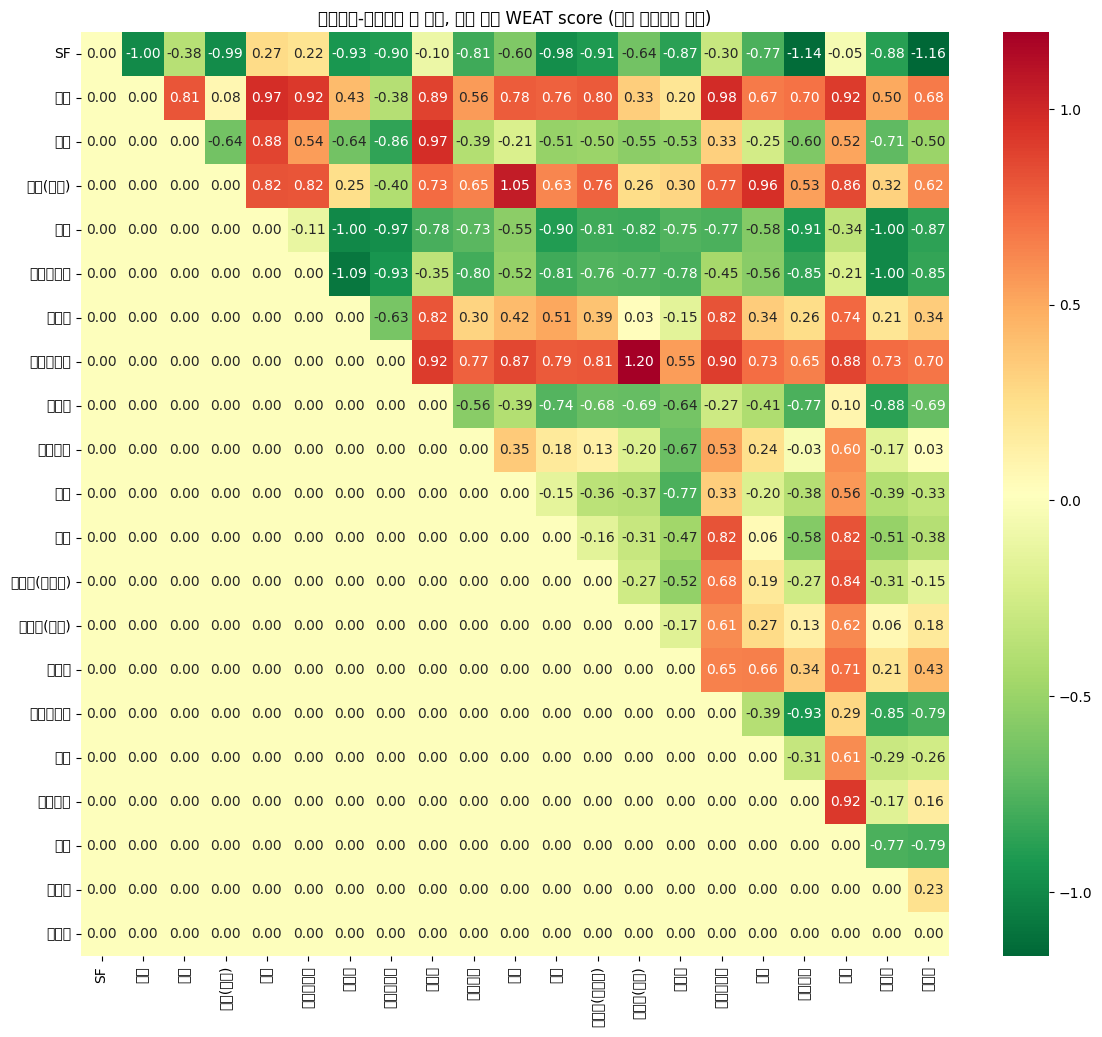

In [ ]:
# 히트맵 시각화. matrix는 i<j인 칸(위쪽 삼각형)에만 값이 있고 나머지는 0이다.
# 대각선 아래가 0으로 보이는 건 "편향이 없다"는 의미가 아니라 계산을 안 한 것뿐이라는 점에 유의해야 한다.
plt.figure(figsize=(14, 12))
sns.heatmap(matrix, xticklabels=genre_name, yticklabels=genre_name,
            annot=True, fmt=".2f", cmap='RdYlGn_r')
plt.title("예술영화-일반영화 축 기준, 장르 쌍별 WEAT score (위쪽 삼각형만 유효)")
plt.show()


**해석 시 주의할 점**: 이 matrix의 (A장르, B장르) 칸 값은 "A와 B를 비교했을 때 어느 쪽이 예술영화에 더 가까운가"라는 **상대적** 비교다. 절댓값이 클수록 두 장르 사이의 편향 차이가 뚜렷하다는 뜻이지, "A는 예술영화, B는 일반영화"라는 절대적인 결론을 내릴 수 있는 건 아니다.

### 전체 코드 실행 흐름

```
[synopsis.txt 전체] --Okt 명사추출--> tokenized --Word2Vec 학습--> model            (STEP1 -> STEP2)

[synopsis_art.txt, synopsis_gen.txt] --read_token()(Okt 명사추출)--> art, gen
                                      --TF-IDF(2개 문서 비교)--> target_art, target_gen        (STEP1 -> STEP3)

[21개 장르 .txt] --read_token()--> genre_all
                 --TF-IDF(21개 문서 동시 비교 + 상호 중복 제거)--> attributes_all               (STEP1 -> STEP3)

target_art, target_gen(X,Y) + attributes_all(A,B 조합) --weat_score()--> 21x21 matrix           (STEP4)
                                                                              |
                                                                      seaborn heatmap 시각화
```

## 회고

**배운 점**
- TF-IDF를 개념 설명으로만 알고 있었는데, 이번 프로젝트에서 장르를 대표하는 단어를 뽑는 용도로 써보니 IDF 공식에서 몇 개의 문서를 한 번에 비교하느냐(n)에 따라 결과가 달라진다는 걸 체감했다. (target은 문서 2개, attribute는 문서 21개로 비교 기준 자체가 달랐던 부분에서 특히 그랬다.)

**아쉬운 점**
- 21개 장르 처리에 시간이 오래 걸려서 여러 번 실험해보기 어려웠다. 또한 결과로 나온 값이 생각보다 연관성이 낮아보였다.

**느낀 점**
- 모델의 결과가 마음에 차지 않아서 개선하고 싶은데, 개선할 수 있는 방법을 떠올리기 어려웠다. 개선에 대한 공부가 부족함을 깨달았다.

